## 🔧 Configuración inicial

Esta celda carga todas las librerías necesarias y descarga los datos. **Ejecútala siempre en primer lugar.**

In [1]:
# ─── Librerías ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy.stats import pearsonr
import scipy.stats as stats
from scipy.stats import gaussian_kde
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ─── Cargar datos ─────────────────────────────────────────────────────────────
URL_DATOS = "https://github.com/jose-rojasquiroz/jose-rojasquiroz.github.io/raw/main/teaching/srgvua_25_26/data/ofertas-bcn_mun-viv_ven.gpkg"
## Si el URL es distinto, deben cambiarlo aquí

print("⏳ Descargando datos...")
gdf = gpd.read_file(URL_DATOS)
print(f"✅ Datos cargados: {gdf.shape[0]:,} filas × {gdf.shape[1]} columnas")
print(f"   Proyección: {gdf.crs}")

⏳ Descargando datos...
✅ Datos cargados: 9,168 filas × 48 columnas
   Proyección: EPSG:25831


In [2]:
print(gdf.columns.to_list())

['codigo_inmueble', 'precio_euros', 'superficie', 'n_habs', 'n_baños', 'planta', 'obra_nueva', 'terraza_grande', 'ascensor', 'ac', 'calefaccion', 'antiguedad', 'calidad_construccion', 'EPC_e_original', 'EPC_e_calculado', 'EPC_coincidente', 'reduccion_precio', 'distancia_plaza_cat', 'distancia_fr_macia', 'primera_linea_mar', 'okupa', 'alquilado', 'cedula', 'plurifam', 'tipo_atico', 'tipo_duplex', 'tipo_estudio', 'tipo_loft', 'tipo_piso', 'tipo_triplex', 'parking', 'trastero', 'Description', 'lat', 'lon', 'dataset_year', 'desemp_pct', 'viv_prip_pct', 'edu_sup_pct', 'rm_h', 'tam_h', 'area_parques_m2', 'acceso_gran_parque', 'num_tp', 'interac_planta_ascensor', 'precio_unitario', 'tract_id_adjusted', 'geometry']


### 🛠️ Funciones auxiliares

Las funciones de este cuaderno están centralizadas aquí. No es necesario modificarlas, pero puedes leerlas para entender cómo funcionan.


In [3]:
# ─── Funciones auxiliares ────────────────────────────────────────────────────

def tabla_vif(X_df, variables, nombre_modelo=''):
    """
    Muestra la tabla de VIF (Factor de Inflación de la Varianza).
    VIF > 5 → multicolinealidad moderada; VIF > 10 → severa.
    """
    vif = pd.DataFrame({
        'Variable': variables,
        'VIF': [variance_inflation_factor(X_df.values, i + 1)
                for i in range(len(variables))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    vif['VIF'] = vif['VIF'].round(2)

    titulo = f"TABLA DE VIF{' — ' + nombre_modelo if nombre_modelo else ''}"
    print(titulo)
    display(vif)


def stepwise_aic(y, vars_forzadas, vars_candidatas, datos):
    """
    Selección de variables por AIC (forward-backward stepwise).
    - vars_forzadas  : siempre presentes en el modelo.
    - vars_candidatas: se evalúan para entrar o salir del modelo.
    Retorna la lista final de variables seleccionadas (incluyendo las forzadas).
    """
    incluidas  = list(vars_forzadas)
    candidatas = list(vars_candidatas)
    aic_actual = sm.OLS(y, sm.add_constant(datos[incluidas])).fit().aic
    mejora     = True

    while mejora:
        mejora = False

        # ── Forward: probar añadir cada candidata ──
        mejor_aic_fwd, mejor_add = aic_actual, None
        for var in candidatas:
            aic_p = sm.OLS(y, sm.add_constant(datos[incluidas + [var]])).fit().aic
            if aic_p < mejor_aic_fwd:
                mejor_aic_fwd, mejor_add = aic_p, var
        if mejor_add:
            incluidas.append(mejor_add)
            candidatas.remove(mejor_add)
            aic_actual = mejor_aic_fwd
            mejora = True

        # ── Backward: probar eliminar las no forzadas ──
        mejor_aic_bwd, mejor_rem = aic_actual, None
        for var in [v for v in incluidas if v not in vars_forzadas]:
            vars_sin = [v for v in incluidas if v != var]
            aic_p = sm.OLS(y, sm.add_constant(datos[vars_sin])).fit().aic
            if aic_p < mejor_aic_bwd:
                mejor_aic_bwd, mejor_rem = aic_p, var
        if mejor_rem:
            incluidas.remove(mejor_rem)
            candidatas.append(mejor_rem)
            aic_actual = mejor_aic_bwd
            mejora = True

    return incluidas


def diagnostico_residuos(modelo, titulo='Modelo'):
    """
    Genera un gráfico P-P y un gráfico de homocedasticidad para un modelo OLS.
    """
    residuos          = modelo.resid
    valores_ajustados = modelo.fittedvalues
    resid_std         = (residuos - residuos.mean()) / residuos.std()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Gráfico P-P ──
    n         = len(resid_std)
    probs_obs = np.arange(1, n + 1) / (n + 1)
    probs_teo = stats.norm.cdf(np.sort(resid_std))
    axes[0].scatter(probs_teo, probs_obs, alpha=0.5, edgecolors='k', s=15, color='steelblue')
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Referencia (normal perfecta)')
    axes[0].set_xlabel('Probabilidades teóricas (normal)', fontsize=10)
    axes[0].set_ylabel('Probabilidades observadas', fontsize=10)
    axes[0].set_title(f'Gráfico P-P — {titulo}', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)

    # ── Homocedasticidad ──
    axes[1].scatter(valores_ajustados, resid_std, alpha=0.4, s=15,
                    color='tomato', edgecolors='k', linewidths=0.3)
    axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Valores ajustados (ŷ)', fontsize=10)
    axes[1].set_ylabel('Residuos estandarizados', fontsize=10)
    axes[1].set_title(f'Homocedasticidad — {titulo}', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print("✅ Funciones auxiliares definidas: tabla_vif | stepwise_aic | diagnostico_residuos")


✅ Funciones auxiliares definidas: tabla_vif | stepwise_aic | diagnostico_residuos


---
## Paso 0 — Análisis Exploratorio de Datos (EDA)

En este paso revisamos la distribución de las variables de interés antes de construir ningún modelo.

> **¿Por qué es importante?** Entender cómo se distribuyen los datos nos permite detectar valores atípicos (*outliers*), asimetría, o variables que pueden necesitar transformación (como aplicar logaritmos).

In [4]:
# ✏️ MODIFICA AQUÍ — Lista de variables a explorar
# Puedes añadir o eliminar variables de esta lista.
# Todas deben ser columnas existentes en el dataset.
VARIABLES_EDA = [
    'precio_euros',
    'precio_unitario',
    'superficie',
    'n_habs',
    'antiguedad',
    'calidad_construccion',
    'rm_h',
    'desemp_pct',
    'distancia_plaza_cat',
]

In [5]:
# ─── Tabla de estadísticas descriptivas ──────────────────────────────────────
desc = gdf[VARIABLES_EDA].describe().T
desc['missing'] = gdf[VARIABLES_EDA].isna().sum()
desc['missing_%'] = (desc['missing'] / len(gdf) * 100).round(1)
display(desc.round(2))

,count,mean,std,min,25%,50%,75%,max,missing,missing_%
precio_euros,9168.0,490412.30,380339.09,20000.00,250000.00,380000.00,580000.00,4810000.00,0,0.0
precio_unitario,9168.0,4790.31,2058.63,250.00,3428.57,4461.54,5750.00,23944.44,0,0.0
superficie,9168.0,96.76,41.33,30.00,70.00,85.00,110.00,260.00,0,0.0
n_habs,9168.0,2.93,1.00,1.00,2.00,3.00,3.00,8.00,0,0.0
antiguedad,9168.0,65.70,31.75,0.00,51.00,63.00,87.00,125.00,0,0.0
calidad_construccion,9168.0,3.88,1.18,1.00,3.00,4.00,5.00,7.00,0,0.0
rm_h,9168.0,45110.32,13861.29,25785.29,35502.24,42016.82,50102.50,98221.00,0,0.0
desemp_pct,9168.0,0.11,0.04,0.03,0.08,0.10,0.13,0.28,0,0.0
distancia_plaza_cat,9168.0,2964.79,1727.41,213.65,1542.13,2746.97,4047.59,8987.24,0,0.0


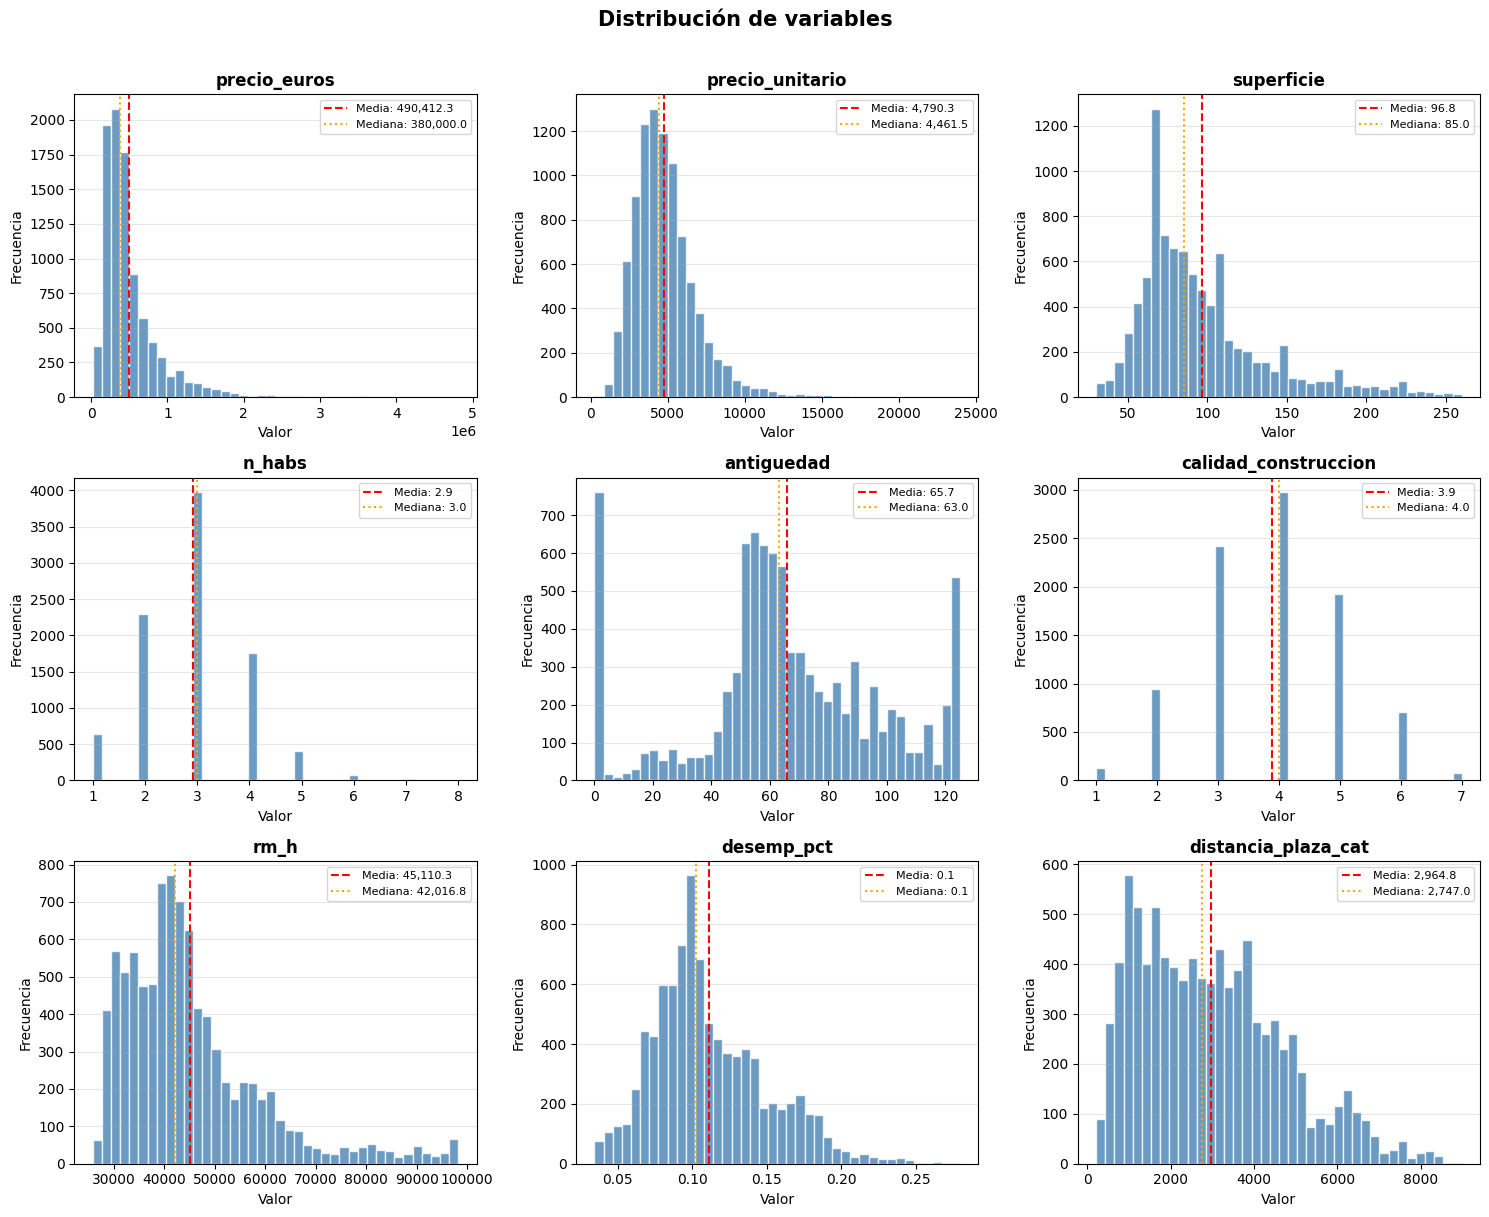

In [6]:
# ─── Histogramas de distribución ─────────────────────────────────────────────
# Se generan automáticamente tantos gráficos como variables haya en VARIABLES_EDA

n_vars = len(VARIABLES_EDA)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # Convertir la rejilla en lista para iterar fácilmente

for i, var in enumerate(VARIABLES_EDA): # Noten que VARIABLES_EDA se define al inicio
    datos_var = gdf[var].dropna()
    axes[i].hist(datos_var, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    
    # Añadir línea de mediana y media
    axes[i].axvline(datos_var.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {datos_var.mean():,.1f}')
    axes[i].axvline(datos_var.median(), color='orange', linestyle=':', linewidth=1.5, label=f'Mediana: {datos_var.median():,.1f}')
    
    axes[i].set_title(var, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3, axis='y')

# Ocultar paneles sobrantes
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

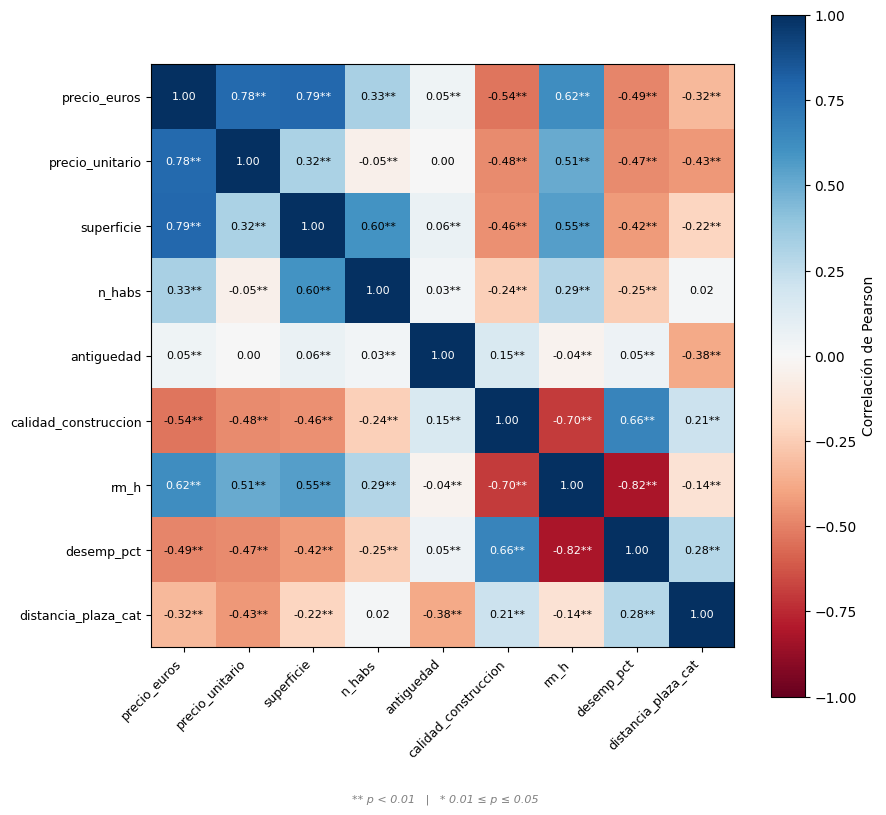

In [7]:
# ─── Matriz de correlaciones ──────────────────────────────────────────────────
# Sólo se incluyen las variables numéricas seleccionadas en ###### VARIABLES_EDA ######

from scipy.stats import pearsonr

corr_matrix = gdf[VARIABLES_EDA].corr() # Noten que VARIABLES_EDA se define al inicio

# Calcular matriz de p-values (correlación de Pearson por pares)
pval_matrix = pd.DataFrame(np.ones((len(VARIABLES_EDA), len(VARIABLES_EDA))),
                            index=VARIABLES_EDA, columns=VARIABLES_EDA)
for i, var1 in enumerate(VARIABLES_EDA):
    for j, var2 in enumerate(VARIABLES_EDA):
        if i != j:
            datos_par = gdf[[var1, var2]].dropna()
            if len(datos_par) > 2:
                _, pval = pearsonr(datos_par[var1], datos_par[var2])
                pval_matrix.iloc[i, j] = pval

fig, ax = plt.subplots(figsize=(max(8, n_vars), max(6, n_vars - 1)))

im = ax.imshow(corr_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlación de Pearson')

# Etiquetas de ejes
ax.set_xticks(range(len(VARIABLES_EDA)))
ax.set_yticks(range(len(VARIABLES_EDA)))
ax.set_xticklabels(VARIABLES_EDA, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(VARIABLES_EDA, fontsize=9)

# Escribir el valor dentro de cada celda
for i in range(len(VARIABLES_EDA)):
    for j in range(len(VARIABLES_EDA)):
        val = corr_matrix.iloc[i, j]
        pval = pval_matrix.iloc[i, j]
        color_texto = 'white' if abs(val) > 0.6 else 'black'

        # Asteriscos de significación (solo fuera de la diagonal)
        if i != j:
            if pval < 0.01:
                stars = '**'
            elif pval <= 0.05:
                stars = '*'
            else:
                stars = ''
        else:
            stars = ''

        ax.text(j, i, f'{val:.2f}{stars}', ha='center', va='center', fontsize=8, color=color_texto)

# Nota al pie con la leyenda de significación
fig.text(0.5, -0.01,
         '** p < 0.01   |   * 0.01 ≤ p ≤ 0.05',
         ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()


---
## Paso 1 — Modelos OLS con selección *stepwise* por AIC

Se construirán dos modelos:
- **Modelo A**: variable dependiente = `precio_euros`
- **Modelo B**: variable dependiente = `log_precio_euros` (logaritmo natural del precio)

En ambos casos:
- Las variables `superficie` y `superficie_2` (superficie al cuadrado) se incluyen siempre.
- El resto de variables se seleccionan automáticamente usando un procedimiento *stepwise* que minimiza el **AIC** (Criterio de Información de Akaike).

> **¿Qué es el AIC?** Es una medida que penaliza la complejidad del modelo. Un AIC más bajo indica un mejor equilibrio entre ajuste y parsimonia (no usar más variables de las necesarias).

In [8]:
# ✏️ MODIFICA AQUÍ — Variables candidatas para el stepwise
# Estas variables se evaluarán una a una; el algoritmo decide cuáles incluir.
# Las variables 'superficie' y 'superficie_2' SIEMPRE se incluyen (no las pongas aquí).
VARIABLES_CANDIDATAS = [
    'calidad_construccion',
    'interac_planta_ascensor',
    'desemp_pct',
    'rm_h',
    'viv_prip_pct',
    'ac',
    'calefaccion',
    'n_habs',
    'n_baños',
    'distancia_plaza_cat',
]

Voy a crear variables que son necesarias para el análisis y que no están por defecto en el dataset.

In [9]:
# superficie al cuadrado (necesaria para capturar relaciones no lineales con el precio)
if 'superficie_2' not in gdf.columns:
    gdf['superficie_2'] = gdf['superficie'] ** 2
    print("✅ Variable 'superficie_2' creada")

# logaritmo del precio (ayuda a corregir la asimetría en la distribución del precio)
if 'log_precio_euros' not in gdf.columns:
    gdf['log_precio_euros'] = np.log(gdf['precio_euros'])
    print("✅ Variable 'log_precio_euros' creada")

# Variables siempre incluidas
VARS_FORZADAS = ['superficie', 'superficie_2']
print(f"\n   Variables forzadas: {VARS_FORZADAS}")
print(f"   Variables candidatas para selección: {VARIABLES_CANDIDATAS}")

✅ Variable 'superficie_2' creada
✅ Variable 'log_precio_euros' creada

   Variables forzadas: ['superficie', 'superficie_2']
   Variables candidatas para selección: ['calidad_construccion', 'interac_planta_ascensor', 'desemp_pct', 'rm_h', 'viv_prip_pct', 'ac', 'calefaccion', 'n_habs', 'n_baños', 'distancia_plaza_cat']


In [10]:
# ─── Modelo A: precio_euros ───────────────────────────────────────────────────
print("="*70)
print("MODELO A — Variable dependiente: precio_euros") ## Esto se ajuste según lo que estén haciendo
print("="*70)

# Preparamos datos
todas_vars_A = VARS_FORZADAS + VARIABLES_CANDIDATAS + ['precio_euros']
datos_A = gdf[todas_vars_A].dropna() # Esto dropea (elimina) los NA: filas vacías
y_A = datos_A['precio_euros']

vars_seleccionadas_A = stepwise_aic(y_A, VARS_FORZADAS, VARIABLES_CANDIDATAS, datos_A)

# Estimar modelo final
X_A = sm.add_constant(datos_A[vars_seleccionadas_A])
modelo_A = sm.OLS(y_A, X_A).fit()

print(modelo_A.summary())

# Guardar residuos
gdf['residuos_modelo_A'] = np.nan
gdf.loc[datos_A.index, 'residuos_modelo_A'] = modelo_A.resid.values

MODELO A — Variable dependiente: precio_euros
                            OLS Regression Results                            
Dep. Variable:           precio_euros   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     2401.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:12:44   Log-Likelihood:            -1.2429e+05
No. Observations:                9168   AIC:                         2.486e+05
Df Residuals:                    9155   BIC:                         2.487e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

In [11]:
tabla_vif(X_A, vars_seleccionadas_A, 'Modelo A (precio_euros)')

TABLA DE VIF — Modelo A (precio_euros)


,Variable,VIF
0,superficie,27.50
1,superficie_2,22.87
2,rm_h,4.79
3,desemp_pct,4.03
4,n_baños,2.23
5,viv_prip_pct,2.21
6,calidad_construccion,2.16
7,distancia_plaza_cat,2.09
8,n_habs,1.79
9,calefaccion,1.40


In [12]:
# ─── Modelo B: log_precio_euros ───────────────────────────────────────────────
print("="*70)
print("MODELO B — Variable dependiente: log_precio_euros")
print("="*70)

todas_vars_B = VARS_FORZADAS + VARIABLES_CANDIDATAS + ['log_precio_euros']
datos_B = gdf[todas_vars_B].dropna()  # Esto dropea (elimina) los NA: filas vacías
y_B = datos_B['log_precio_euros']

vars_seleccionadas_B = stepwise_aic(y_B, VARS_FORZADAS, VARIABLES_CANDIDATAS, datos_B)

# Estimar modelo final
X_B = sm.add_constant(datos_B[vars_seleccionadas_B])
modelo_B = sm.OLS(y_B, X_B).fit()

print(modelo_B.summary())

# Guardar residuos
gdf['residuos_modelo_B'] = np.nan
gdf.loc[datos_B.index, 'residuos_modelo_B'] = modelo_B.resid.values

MODELO B — Variable dependiente: log_precio_euros
                            OLS Regression Results                            
Dep. Variable:       log_precio_euros   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     3926.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:12:45   Log-Likelihood:                -686.88
No. Observations:                9168   AIC:                             1400.
Df Residuals:                    9155   BIC:                             1492.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [13]:
tabla_vif(X_B, vars_seleccionadas_B, 'Modelo B (log_precio_euros)')

TABLA DE VIF — Modelo B (log_precio_euros)


,Variable,VIF
0,superficie,27.50
1,superficie_2,22.87
2,rm_h,4.79
3,desemp_pct,4.03
4,n_baños,2.23
5,viv_prip_pct,2.21
6,calidad_construccion,2.16
7,distancia_plaza_cat,2.09
8,n_habs,1.79
9,calefaccion,1.40


---
## Paso 2 — Diagnóstico de residuos

Para cada modelo se generan dos gráficos:
1. **Gráfico P-P**: compara la distribución de los residuos con una distribución normal. Si los puntos siguen la línea roja, los residuos son normales.
2. **Gráfico de homocedasticidad**: muestra si los residuos tienen varianza constante. Idealmente, los puntos deben dispersarse sin patrón alrededor del cero.

> **¿Por qué importa?** La validez de los test estadísticos del OLS depende de que los residuos sean normales y homocedásticos (varianza constante).

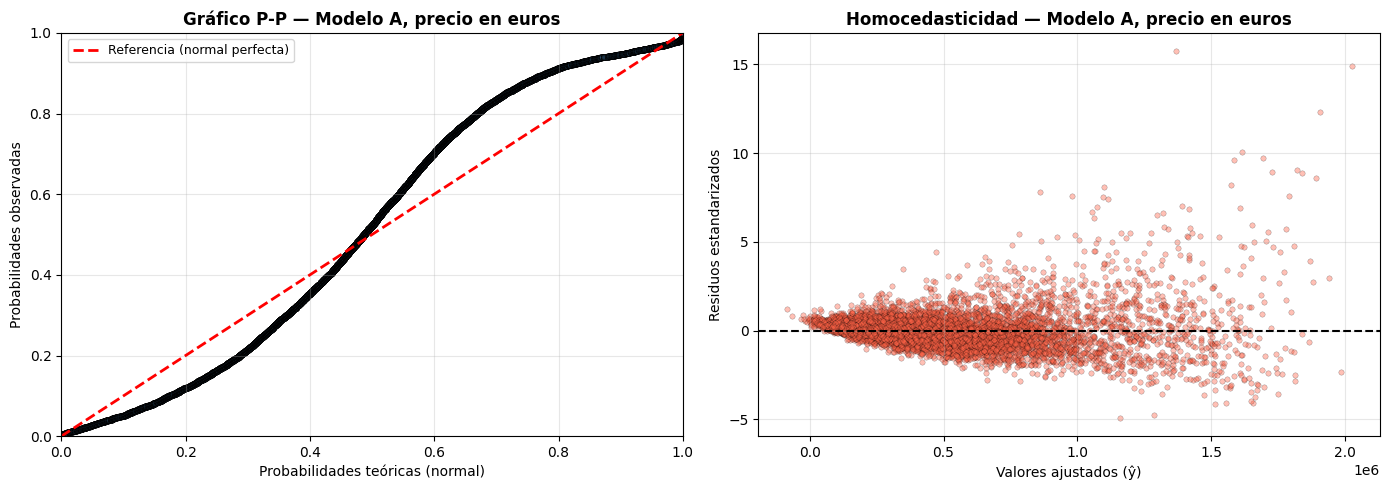

In [14]:
# Diagnóstico del Modelo A (precio_euros)
diagnostico_residuos(modelo_A, titulo='Modelo A, precio en euros')

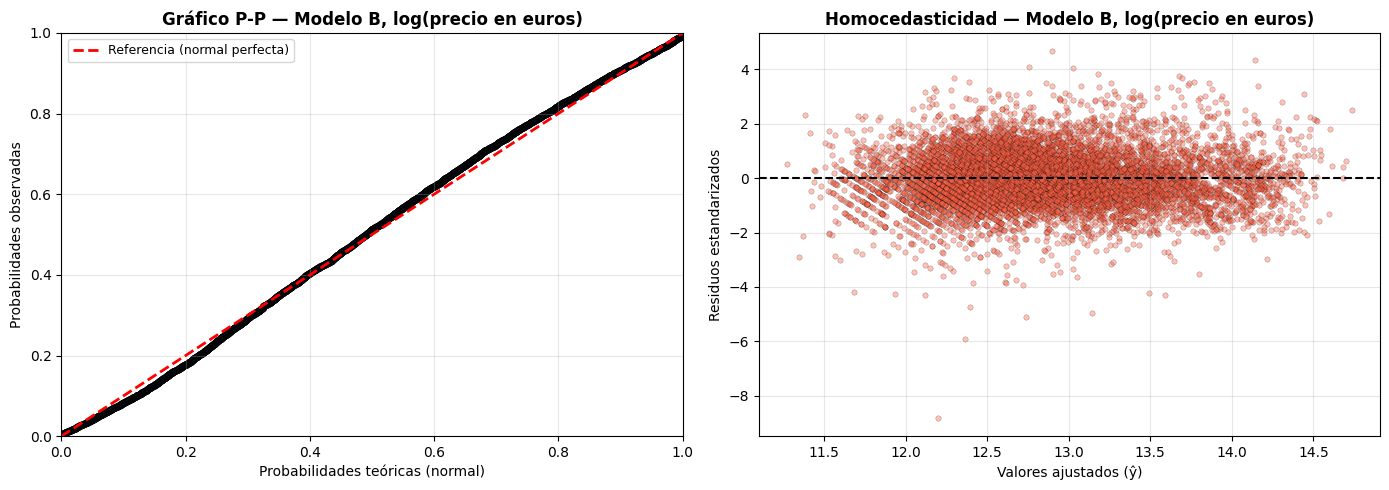

In [15]:
# Diagnóstico del Modelo B (log_precio_euros)
diagnostico_residuos(modelo_B, titulo='Modelo B, log(precio en euros)')

---
## Paso 3 — Modelo OLS definitivo (variables fijas)

A diferencia del Paso 1, aquí **no se usa selección automática**. Las variables explicativas se definen directamente.

La variable dependiente es `log_precio_euros`.

> **Nota:** Este es el modelo que se usará en el Cuaderno 2 para el análisis espacial y la comparación con XGBoost. Por eso al final se guarda como archivo para poder cargarlo desde allí.

In [16]:
# ✏️ MODIFICA AQUÍ — Variables del modelo definitivo
# Estas se incluyen directamente, sin selección automática.
# 'superficie' y 'superficie_2' son siempre obligatorias.
VARS_MODELO_DEFINITIVO = [
    'superficie',
    'superficie_2',
    'calidad_construccion',
    'interac_planta_ascensor',
    'distancia_plaza_cat',
    'distancia_fr_macia',
    'num_tp',
]

In [17]:
# ─── Estimar modelo definitivo ────────────────────────────────────────────────

datos_def = gdf[VARS_MODELO_DEFINITIVO + ['log_precio_euros']].dropna()
y_C = datos_def['log_precio_euros']
X_C = sm.add_constant(datos_def[VARS_MODELO_DEFINITIVO])

modelo_C = sm.OLS(y_C, X_C).fit()

print("="*70)
print("MODELO C — Variable dependiente: log_precio_euros")
print("="*70)
print(modelo_C.summary())

# Guardar residuos en el GeoDataFrame
gdf['residuos_ols_C'] = np.nan
gdf.loc[datos_def.index, 'residuos_ols_C'] = modelo_C.resid.values

print(f"\n✅ Residuos guardados en columna 'residuos_ols_C'")

MODELO C — Variable dependiente: log_precio_euros
                            OLS Regression Results                            
Dep. Variable:       log_precio_euros   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     4543.
Date:                Tue, 03 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:12:48   Log-Likelihood:                -2145.5
No. Observations:                9168   AIC:                             4307.
Df Residuals:                    9160   BIC:                             4364.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [18]:
tabla_vif(X_C, VARS_MODELO_DEFINITIVO, 'Modelo C')

TABLA DE VIF — Modelo C


,Variable,VIF
0,superficie,22.43
1,superficie_2,21.55
2,distancia_fr_macia,3.15
3,distancia_plaza_cat,2.49
4,calidad_construccion,1.79
5,interac_planta_ascensor,1.16
6,num_tp,1.04


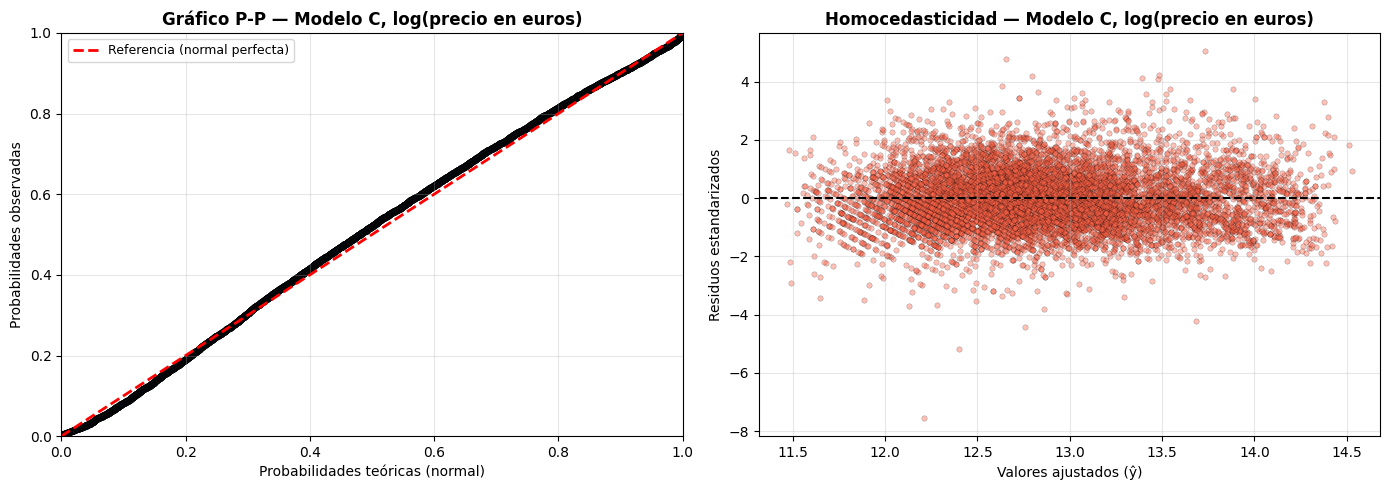

In [19]:
# Diagnóstico de residuos del modelo C
diagnostico_residuos(modelo_C, titulo='Modelo C, log(precio en euros)')                                 

---
## 💾 Guardar datos para un próximo análisis

La siguiente celda monta Google Drive y guarda el dataset (con todos los residuos y variables creadas) como un archivo `.gpkg`.

Primero, le damos permiso a Google Colab para conectarse a nuestro Google Drive. Cuando se ejecute, Google te pedirá permiso para acceder a tu Drive: acéptalo.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# ✏️ MODIFICA AQUÍ 
# Aquí definimos la ruta dentro de Google Drive donde guardar el archivo
# (La carpeta se creará automáticamente si no existe)
ruta_salida = "/content/drive/MyDrive/srgvua/datos_para_cuaderno2.gpkg" # La parte de /content/drive/MyDrive/ se debe mantener siempre
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

Y ahora sí guardamos.

In [22]:
# ─── Guardar ──────────────────────────────────────────────────────────────────
gdf.to_file(ruta_salida, driver='GPKG')